:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`define_a_custom_basis.ipynb`**!

:::


# How to Define A Custom Basis Class

If you want to design features that are not covered by our collection of basis functions, you can create a custom basis class using [`CustomBasis`](nemos.basis._custom_basis.CustomBasis). To do so, simply provide a list of functions when initializing the `CustomBasis` object.

Below, we define a **parametric family** of functions—Laguerre polynomials—and fix their parameters using [`functools.partial`](https://docs.python.org/3/library/functools.html#functools.partial). (See the admonition below for why we avoid using `lambda` functions in this context.)

As with any other basis, a `CustomBasis` can be composed with other basis objects in the usual way.

## Example: Laguerre Polynomials

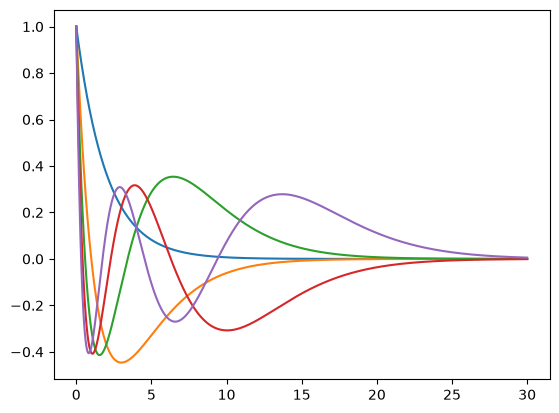

(1000, 10)


In [1]:
import jax.numpy as jnp
import numpy as np
from scipy.special import laguerre
import matplotlib.pyplot as plt
import nemos as nmo
from functools import partial

x = jnp.linspace(0, 30, 1000)
c = 1.0
N = 5
P = np.zeros((N, N))
for n in range(N):
    P[n, :(n+1)] = laguerre(n).coef[::-1]
P = jnp.array(P)

def laguerre_poly(poly_coef, decay_rate, x):
    """
    Laguerre polynomial.

    Evaluate a single basis function with polynomial coefficients `p` at
    position `x` with decay time constant `c`.
    """
    exp_decay = jnp.exp(-decay_rate * x/2)
    return exp_decay * jnp.polyval(poly_coef[::-1], decay_rate * x)

funcs = [partial(laguerre_poly, p, c) for p in P]

bas = nmo.basis.CustomBasis(funcs=funcs, label="Laguerre")

features = bas.compute_features(x)

# Plot basis functions.
plt.plot(x, bas.compute_features(x))
plt.show()

# Add two Laguerre Poly
add = bas + nmo.basis.CustomBasis(funcs=funcs, label="Laguerre-2")
print(add.compute_features(x, x).shape)

:::{admonition} Python Warning
:class: warning

Replacing `functools.partial` with a `lambda` function would not work.

```{code} ipython
funcs = [lambda x: laguerre_poly(p, c, x) for p in P]
```

This will create a list of identical Laguerre polynomial functions. Why? Because `p` is captured by reference, not by value. When each lambda is called, it uses the value of `p` at that moment — which will be the last value in `P`, for all functions.

In contrast, `functools.partial` evaluates its arguments immediately, so each function correctly captures its own `p` value, avoiding this issue.
:::

## Multi-dimensional Outputs

Custom basis works with multi-dimensional outputs as well. Continuing on the Laguerre polynomial example, let's assume that we want to take advantage of the `JAX` vmap capability for efficiency. We can create a single basis that maps a sample to a 5-dimensional output as follows.

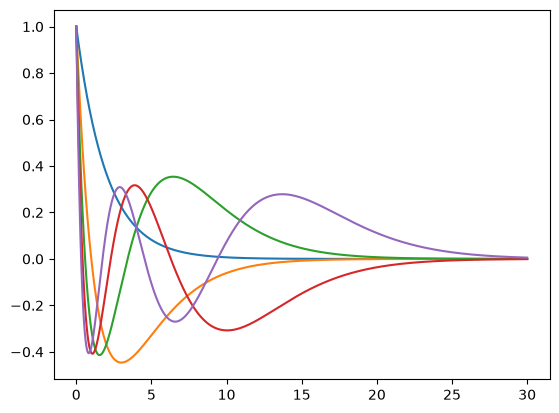

In [2]:
import jax

# vmap_laguerre: R -> R^5
vmap_laguerre = jax.vmap(laguerre_poly, in_axes=(0, None, None), out_axes=1)

# a single function can be provided directly (i.e. not wrapped in a list)
bas_vmap = nmo.basis.CustomBasis(funcs=partial(vmap_laguerre, P, c), label="Laguerre-vmap")

# Plot basis functions.
plt.plot(x, bas_vmap.compute_features(x))
plt.show()

:::{admonition} Python Warning #2
:class: warning

Using `partial` with **keyword arguments** in combination with a `vmap`-ed function will not work as expected. This is because `jax.vmap` applies `in_axes` only to **positional arguments**, and the number of positional arguments must match the length of `in_axes`.

In the example below, only `x` is passed positionally, so `vmap` sees just one argument—causing a mismatch with `in_axes=(0, None, None)`.

```{code} ipython3

import inspect

# partial() will bind 'poly_coef' and 'decay_rate'
# as keyword arguments, leaving 'x' as a keyword-only parameter.
vmap_laguerre = jax.vmap(laguerre_poly, in_axes=0, out_axes=1)
f = partial(vmap_laguerre, poly_coef=P, decay_rate=c)
print(inspect.signature(f))

# Calling f(x) positionally confuses vmap’s shape inference (it expects three positional args),
# so it fails with a shape/axis error before reaching laguerre_poly.
f(x)

```
:::

## Multi-dimensional Inputs

A custom basis can also receive a multi-dimensional input. As an example, let's write down a basis that acts on image inputs, and computes the dot product of an image with a bank of filter masks.

(100, 64)


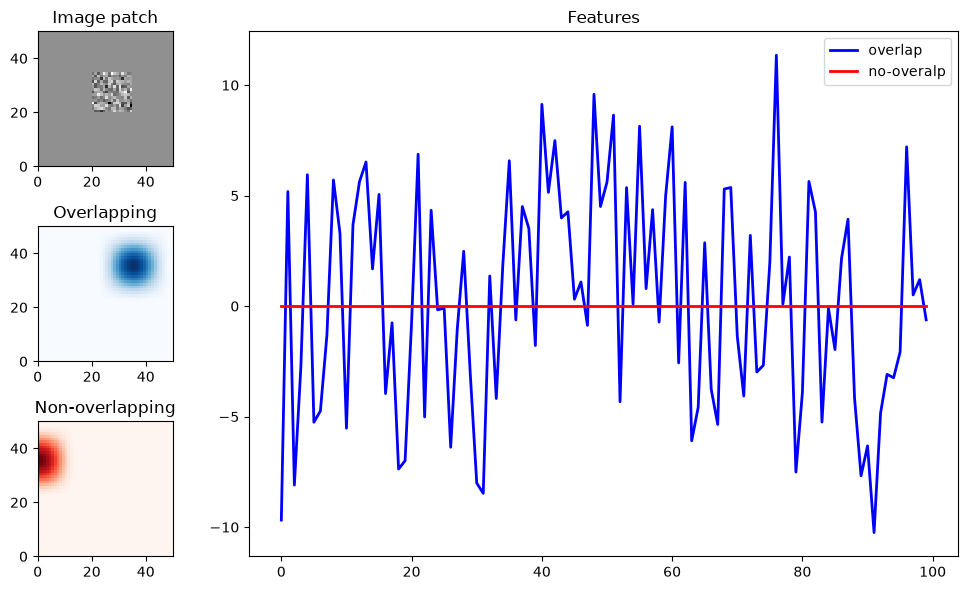

In [3]:
import matplotlib.gridspec as gridspec

# generate 100 random noise 50 x 50 images and crop a patch
imgs = np.random.randn(100, 50, 50)
crop = np.zeros((1, 50, 50))
crop[0, 20:35, 20:35] = 1
imgs *= crop

def image_dot_product(img, mask):
    return jnp.sum(img * mask[None], axis=(1,2))

# define masks using a nemos 2D basis
basis_2d = nmo.basis.RaisedCosineLinearEval(8)**2
_, _, masks = basis_2d.evaluate_on_grid(50, 50)
funcs = [partial(image_dot_product, mask=m) for m in masks.T]

# specify the the expected 3D input, (n_samples, pixel, pixel)
bas_img = nmo.basis.CustomBasis(funcs=funcs, ndim_input=3, label="Image-dot")
features = bas_img.compute_features(imgs)
print(features.shape)

# plot two features, one corrresponding to a mask
# that overlaps with the patch, one that doesn't
fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(3, 4, figure=fig)
ax = fig.add_subplot(gs[0, 0])
ax.set_aspect('equal')
ax.pcolormesh(imgs[0], cmap="Greys")
ax.set_title("Image patch")

ax = fig.add_subplot(gs[1, 0])
ax.set_aspect('equal')
ax.set_title("Overlapping")
ax.pcolormesh(masks[..., 45], cmap="Blues")

ax = fig.add_subplot(gs[2, 0])
ax.set_aspect('equal')
ax.pcolormesh(masks[..., 40], cmap="Reds")
ax.set_title("Non-overlapping")

ax = fig.add_subplot(gs[:, 1:])
ax.set_title("Features")
ax.plot(features[:, 45], color="b", lw=2, label="overlap")
ax.plot(features[:, 40], color="r", lw=2, label="no-overalp")
plt.legend()
fig.tight_layout()
plt.show()